# Import Libraries

In [1]:
!pip install gensim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.6 MB/s eta 0:00:00


# Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Path to dataset files:", path)

100%|██████████| 1.83M/1.83M [00:00<00:00, 47.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yufengdev/bbc-fulltext-and-category/versions/2


# Read Dataset

In [3]:
import pandas as pd
import os

# The file identified by os.listdir(path) is 'bbc-text.csv'.
csv_file_name = 'bbc-text.csv'

# Construct the full path to the CSV file.
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# Text Preprocessing

In [4]:
nltk.download('punkt') # For word tokenization
nltk.download('stopwords') # For stopwords
nltk.download('punkt_tab') # Required for some NLTK tokenization scenarios

# Lowercase
def preprocess_text(text):
  text = text.lower()
  # Remove special character
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # Tokenize and remove stopwords
  words = nltk.word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  words = [w for w in words if w not in stop_words]
  return words

df['tokenized_text'] = df['text'].apply(preprocess_text)
tokenized_data = df['tokenized_text'].tolist()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Train CBOW Model

In [5]:
cbow_model = Word2Vec(sentences = tokenized_data,vector_size=100,# Embedding Size
                      window = 5,   # Context Window
                      min_count = 2, # Ignore rare words
                      sg = 0)  # CBOW

# Train Skip-Gram Model

In [6]:
skipgram_model = Word2Vec(sentences = tokenized_data,vector_size=100,
                          window = 5,
                          min_count = 2,
                          sg = 1)  # Skip Gram

# Compare Similar Words

In [7]:
word = "market"

print("\nCBOW Similar Words:")
print(cbow_model.wv.most_similar(word))

print("\nSkip-Gram Similar Words:")
print(skipgram_model.wv.most_similar(word))


CBOW Similar Words:
[('sales', 0.9435867667198181), ('us', 0.9420821070671082), ('stock', 0.9411358833312988), ('firm', 0.940858006477356), ('prices', 0.936875581741333), ('oil', 0.9359664916992188), ('china', 0.9258435368537903), ('analysts', 0.9219903945922852), ('share', 0.9213982224464417), ('consumer', 0.9204068183898926)]

Skip-Gram Similar Words:
[('manufacturers', 0.7425941824913025), ('markets', 0.7352727055549622), ('operator', 0.7324191927909851), ('stock', 0.7264441251754761), ('heavy', 0.718079686164856), ('slowing', 0.7116031646728516), ('nasdaq', 0.7080873250961304), ('continental', 0.7076875567436218), ('reflecting', 0.704630970954895), ('product', 0.7022519707679749)]


# Cosine Similarity Comparsion

In [9]:
w1, w2 = 'market','economy'

print("\nCBOW Similar Words:")
print(cbow_model.wv.most_similar(w1, w2))

print("\nSkip-Gram Similar Words:")
print(skipgram_model.wv.most_similar(w1, w2))


CBOW Similar Words:
[('sybari', 0.6943243145942688), ('fulltrack', 0.6891540288925171), ('mobile', 0.6511362791061401), ('preorders', 0.6327821612358093), ('music', 0.6273109316825867), ('razr', 0.6066535711288452), ('plaguing', 0.5949721336364746), ('dvrs', 0.5642164349555969), ('snowballed', 0.5562321543693542), ('tiein', 0.553533136844635)]

Skip-Gram Similar Words:
[('buy', 0.40291330218315125), ('ipod', 0.3862696886062622), ('apple', 0.37397080659866333), ('offer', 0.3640498220920563), ('sony', 0.3493029475212097), ('bluray', 0.34369489550590515), ('mac', 0.33799511194229126), ('sale', 0.3372496962547302), ('format', 0.3269745707511902), ('bought', 0.3267661929130554)]


# Visualization using PCA

In [13]:
def plot_embedding(model, title):

  # Top 15 Words
  words = list(model.wv.index_to_key)[:30]
  vector = model.wv[words]

  # Reduce dimensions
  pca = PCA(n_components=2)
  result = pca.fit_transform(vector)

  # Create a scatter plot
  plt.figure(figsize=(10, 6))
  plt.scatter(result[:, 0], result[:, 1])

  for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

  plt.title(title)
  plt.show()

# Plot CBOW

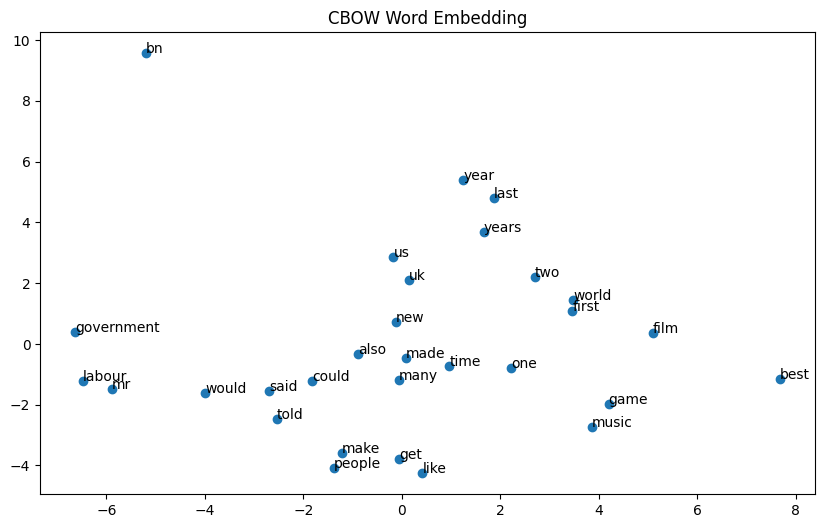

In [14]:
plot_embedding(cbow_model, 'CBOW Word Embedding')

# Plot Skip-Gram

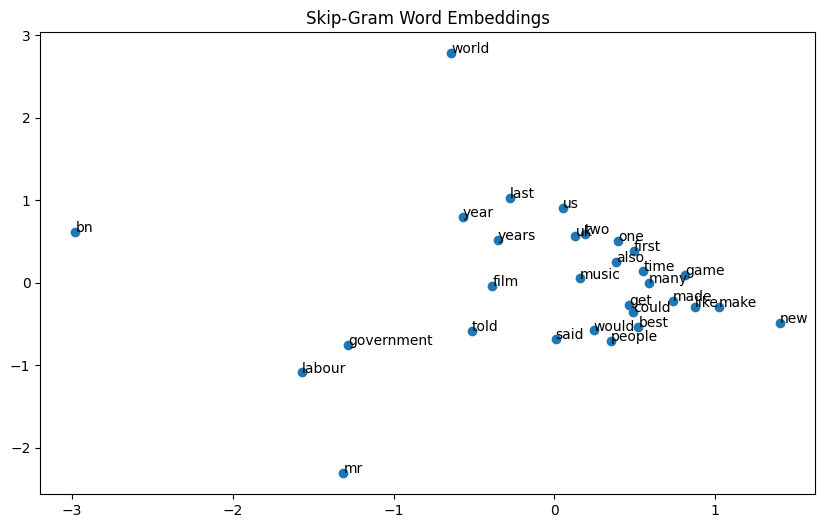

In [15]:
plot_embedding(skipgram_model, 'Skip-Gram Word Embeddings')

# Conclusion

## CBOW
CBOW is faster and works well for frequent words.

## Skip-Gram
Skip-Gram captures better semantic relationship, especially for rare words.